In [201]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [202]:
df = pd.read_csv("../data/Zomato Dataset.csv")

In [203]:
df.head()

,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,Time_Order_picked,Weather_conditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken (min)
0,0xcdcd,DEHRES17DEL01,36.0,4.2,30.327968,78.046106,30.397968,78.116106,12-02-2022,21:55,22:10,Fog,Jam,2,Snack,motorcycle,3.0,No,Metropolitian,46
1,0xd987,KOCRES16DEL01,21.0,4.7,10.003064,76.307589,10.043064,76.347589,13-02-2022,14:55,15:05,Stormy,High,1,Meal,motorcycle,1.0,No,Metropolitian,23
2,0x2784,PUNERES13DEL03,23.0,4.7,18.562450,73.916619,18.652450,74.006619,04-03-2022,17:30,17:40,Sandstorms,Medium,1,Drinks,scooter,1.0,No,Metropolitian,21
3,0xc8b6,LUDHRES15DEL02,34.0,4.3,30.899584,75.809346,30.919584,75.829346,13-02-2022,09:20,09:30,Sandstorms,Low,0,Buffet,motorcycle,0.0,No,Metropolitian,20
4,0xdb64,KNPRES14DEL02,24.0,4.7,26.463504,80.372929,26.593504,80.502929,14-02-2022,19:50,20:05,Fog,Jam,1,Snack,scooter,1.0,No,Metropolitian,41


In [204]:
df.shape

(45584, 20)

In [205]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 45584 entries, 0 to 45583
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   ID                           45584 non-null  str    
 1   Delivery_person_ID           45584 non-null  str    
 2   Delivery_person_Age          43730 non-null  float64
 3   Delivery_person_Ratings      43676 non-null  float64
 4   Restaurant_latitude          45584 non-null  float64
 5   Restaurant_longitude         45584 non-null  float64
 6   Delivery_location_latitude   45584 non-null  float64
 7   Delivery_location_longitude  45584 non-null  float64
 8   Order_Date                   45584 non-null  str    
 9   Time_Orderd                  43853 non-null  str    
 10  Time_Order_picked            45584 non-null  str    
 11  Weather_conditions           44968 non-null  str    
 12  Road_traffic_density         44983 non-null  str    
 13  Vehicle_condition          

In [206]:
(df.isnull().sum()/len(df) )*100

ID                             0.000000
Delivery_person_ID             0.000000
Delivery_person_Age            4.067217
Delivery_person_Ratings        4.185679
Restaurant_latitude            0.000000
Restaurant_longitude           0.000000
Delivery_location_latitude     0.000000
Delivery_location_longitude    0.000000
Order_Date                     0.000000
Time_Orderd                    3.797385
Time_Order_picked              0.000000
Weather_conditions             1.351351
Road_traffic_density           1.318445
Vehicle_condition              0.000000
Type_of_order                  0.000000
Type_of_vehicle                0.000000
multiple_deliveries            2.178396
Festival                       0.500176
City                           2.632503
Time_taken (min)               0.000000
dtype: float64

In [207]:
df.duplicated().sum()

np.int64(0)

## Univarient Analysis

In [208]:
# Target Analysis

df['Time_taken (min)'].describe()

count    45584.000000
mean        26.293963
std          9.384298
min         10.000000
25%         19.000000
50%         26.000000
75%         32.000000
max         54.000000
Name: Time_taken (min), dtype: float64

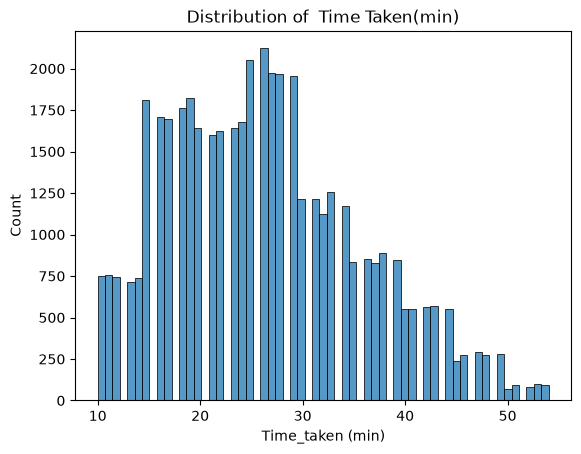

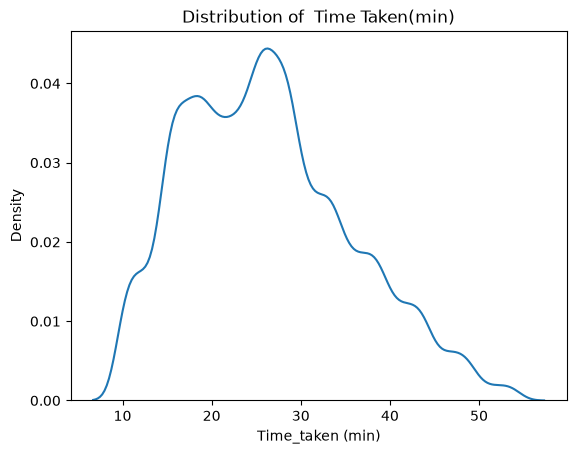

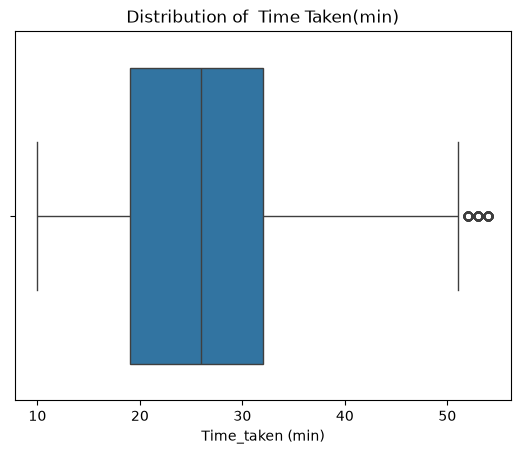

In [209]:
sns.histplot(data=df, x='Time_taken (min)')
plt.title("Distribution of  Time Taken(min)")
plt.show()

sns.kdeplot(data=df, x='Time_taken (min)')
plt.title("Distribution of  Time Taken(min)")
plt.show()

sns.boxplot(data=df, x='Time_taken (min)')
plt.title("Distribution of  Time Taken(min)")
plt.show()

In [210]:
df['Time_taken (min)'].skew()

np.float64(0.4860861249323384)

conclusion-

1. There are no missing values
2. the target variable (Time_taken) is approximately normally distributed with slight positive(right) skewness(0.49) 
3. Most of the distribution is concentrated within the range of 15-30 min
3. boxplot shows some extreme values but those are valid outliers

In [211]:
# categorical Analysis

df.select_dtypes(include='object').columns

C:\Users\Naamdevv Bangge\AppData\Local\Temp\ipykernel_132552\3654852283.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.select_dtypes(include='object').columns


Index(['ID', 'Delivery_person_ID', 'Order_Date', 'Time_Orderd',
       'Time_Order_picked', 'Weather_conditions', 'Road_traffic_density',
       'Type_of_order', 'Type_of_vehicle', 'Festival', 'City'],
      dtype='str')

In [212]:
cat_col = ['Weather_conditions','Road_traffic_density','Type_of_order', 'Type_of_vehicle', 'Festival', 'City', 'multiple_deliveries','Vehicle_condition']

In [213]:
# categorical Distribution

for col in cat_col:
    print(f" Distribution of {col} ")
    print(df[col].value_counts(normalize=True)*100)
    print()

 Distribution of Weather_conditions 
Weather_conditions
Fog           17.018769
Stormy        16.865326
Cloudy        16.751912
Sandstorms    16.665184
Windy         16.505070
Sunny         16.193738
Name: proportion, dtype: float64

 Distribution of Road_traffic_density 
Road_traffic_density
Low       34.404108
Jam       31.431874
Medium    24.331414
High       9.832603
Name: proportion, dtype: float64

 Distribution of Type_of_order 
Type_of_order
Snack     25.293963
Meal      25.131625
Drinks    24.835469
Buffet    24.738943
Name: proportion, dtype: float64

 Distribution of Type_of_vehicle 
Type_of_vehicle
motorcycle          57.978677
scooter             33.505177
electric_scooter     8.366971
bicycle              0.149175
Name: proportion, dtype: float64

 Distribution of Festival 
Festival
No     98.024517
Yes     1.975483
Name: proportion, dtype: float64

 Distribution of City 
City
Metropolitian    76.800198
Urban            22.830299
Semi-Urban        0.369503
Name: proportio

conclusion-

1. there are 34% where traffic density is low , 31% where path is jam and 24% where the traffic is medium
2. orders (%)are almost same among the all types 
3. most of the delivery vehicals are of motorcycle(53%) and scooter(33%) type
4. only about 2% scenario where is festival season is ongoing otherwise no any festival present
5. most of the cities are metropolitian and some of are urban
6. in multiple delivery 63% deliveries are the 2 product delivery and 31% are single deliveries
7. for the delivery person id we need some investigation 

In [214]:
# numeric feature

num_col = ['Delivery_person_Age','Delivery_person_Ratings']

In [215]:
# Distribution of num features

df[num_col].describe()

,Delivery_person_Age,Delivery_person_Ratings
count,43730.000000,43676.000000
mean,29.566911,4.633774
std,5.815064,0.334744
min,15.000000,1.000000
25%,25.000000,4.500000
50%,30.000000,4.700000
75%,35.000000,4.900000
max,50.000000,6.000000


Distribution of Delivery person Age


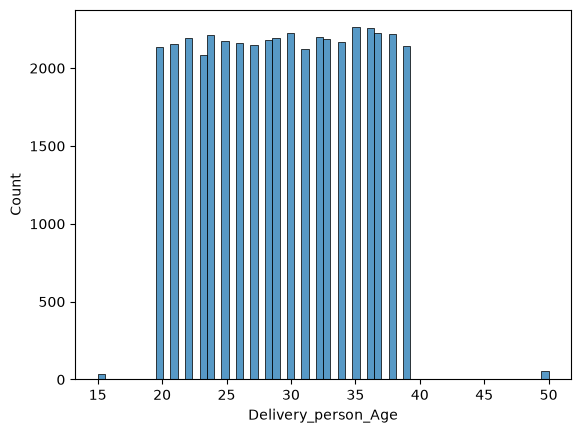

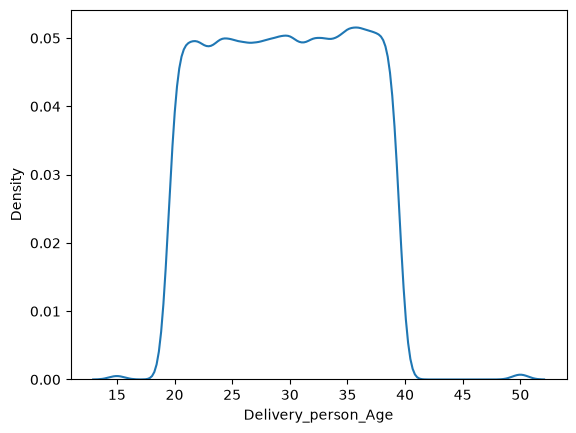

In [216]:
print("Distribution of Delivery person Age")

sns.histplot(data=df, x='Delivery_person_Age')
plt.show()
sns.kdeplot(data=df, x='Delivery_person_Age')
plt.show()
   

<Axes: xlabel='Delivery_person_Age'>

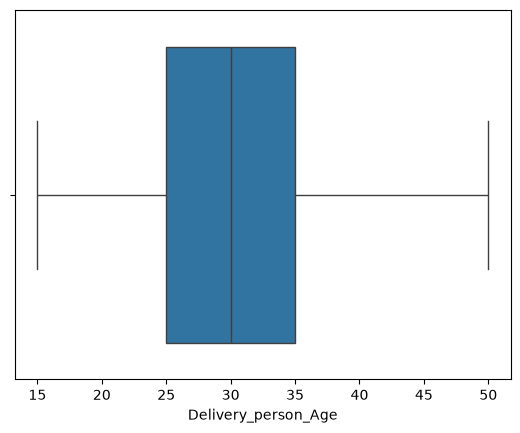

In [217]:
sns.boxplot(data=df, x='Delivery_person_Age')

In [218]:
df['Delivery_person_Age'].skew()

np.float64(0.018771873099854206)

conclusion-

Delivery_person_Age is normally distributed and almost all values are concentrated between 20-40 age range . some delivery persons are very younger like 15 year while some are old like 50 years. there is no outliers in data 

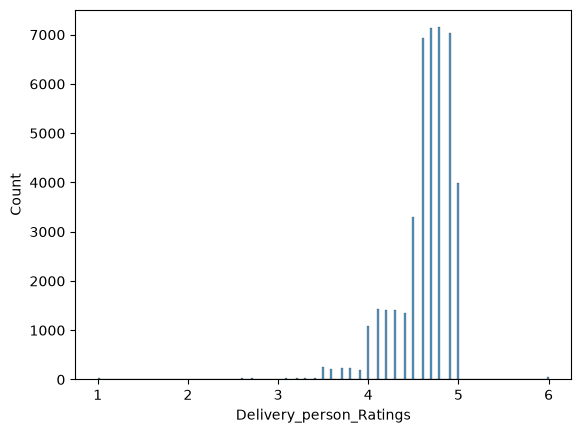

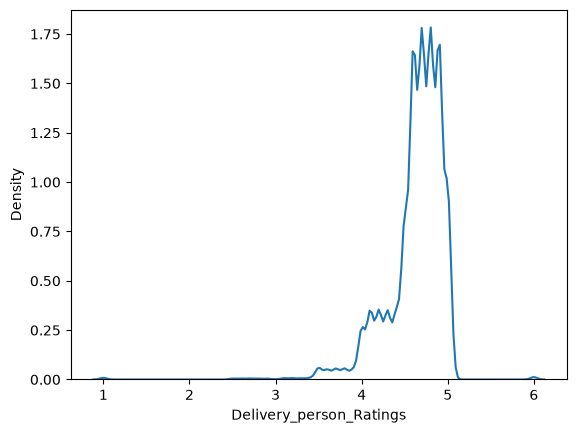

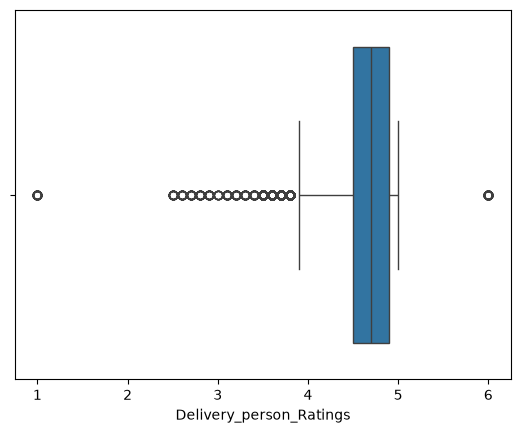

In [219]:
# Delivery_person_Ratings

sns.histplot(data=df,x='Delivery_person_Ratings')
plt.show()

sns.kdeplot(data=df,x='Delivery_person_Ratings')
plt.show()

sns.boxplot(data=df,x='Delivery_person_Ratings')
plt.show()

In [220]:
# df[df['Delivery_person_Ratings'] > 5]

In [221]:
# df[df['Delivery_person_Ratings'] < 2]

In [222]:
pd.crosstab(df['Delivery_person_Age'], df['Delivery_person_Ratings'])

Delivery_person_Ratings,1.0,2.5,2.6,2.7,2.8,2.9,3.0,3.1,3.2,3.3,...,4.2,4.3,4.4,4.5,4.6,4.7,4.8,4.9,5.0,6.0
Delivery_person_Age,,,,,,,,,,,,,,,,,,,,,
15.0,38,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
20.0,0,2,4,2,2,1,0,3,5,0,...,45,32,36,165,342,388,382,405,216,0
21.0,0,3,5,2,2,2,0,3,0,0,...,39,37,37,189,370,406,396,348,228,0
22.0,0,1,3,3,1,2,0,6,1,4,...,50,59,38,176,398,383,392,385,200,0
23.0,0,4,1,1,1,1,0,2,2,3,...,33,38,42,159,357,387,377,391,193,0
24.0,0,0,3,1,3,2,0,1,6,2,...,51,47,55,198,387,394,389,373,206,0
25.0,0,2,1,3,2,5,0,3,1,0,...,57,43,41,193,388,384,357,383,212,0
26.0,0,1,0,3,3,1,0,1,2,2,...,55,41,50,178,359,399,382,380,198,0
27.0,0,2,0,3,1,2,0,1,1,1,...,51,39,51,195,410,364,362,359,209,0


In [223]:
# create new dataframe for suspecious values

suspect = df[ (df['Delivery_person_Ratings'] < 2.5) | (df['Delivery_person_Ratings'] > 5) ]

In [224]:
suspect.describe()

,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Vehicle_condition,multiple_deliveries,Time_taken (min)
count,91.000000,91.000000,91.000000,91.000000,91.000000,91.000000,91.0,91.000000,91.000000
mean,35.384615,3.912088,2.734793,22.616975,15.840926,69.337856,3.0,0.615385,24.802198
std,17.356247,2.479464,17.425157,70.309761,7.721284,24.676014,0.0,0.553157,7.872907
min,15.000000,1.000000,-27.159795,-88.366217,0.010000,0.010000,3.0,0.000000,11.000000
25%,15.000000,1.000000,-13.029780,-74.778292,12.416239,74.894054,3.0,0.000000,19.000000
50%,50.000000,6.000000,11.025083,73.905101,13.129645,77.101082,3.0,1.000000,25.000000
75%,50.000000,6.000000,15.256333,77.611236,22.746541,80.233609,3.0,1.000000,29.000000
max,50.000000,6.000000,30.366322,85.325731,30.436322,88.496217,3.0,2.000000,48.000000


In [225]:
suspect.isnull().sum()/len(suspect)*100

ID                               0.000000
Delivery_person_ID               0.000000
Delivery_person_Age              0.000000
Delivery_person_Ratings          0.000000
Restaurant_latitude              0.000000
Restaurant_longitude             0.000000
Delivery_location_latitude       0.000000
Delivery_location_longitude      0.000000
Order_Date                       0.000000
Time_Orderd                    100.000000
Time_Order_picked                0.000000
Weather_conditions             100.000000
Road_traffic_density           100.000000
Vehicle_condition                0.000000
Type_of_order                    0.000000
Type_of_vehicle                  0.000000
multiple_deliveries              0.000000
Festival                         0.000000
City                             2.197802
Time_taken (min)                 0.000000
dtype: float64

conclusion-


- All rating excepts outliers are distributed between 2.5-5 and most rating is concentrated between the range of 4.5 - 5
- There are some suspecious values/ outliers are determined in this column (Delivery_person_Ratings) like rating 6 and 1 having the highly systematic anomaly involving age , vehicle condition 
- also all values for traffic density, weather condition and time ordered are missing 
- these records require investigation before treatment



for other columns we need some investigation nad feature engg so we will do that later

## Bivarient Analysis

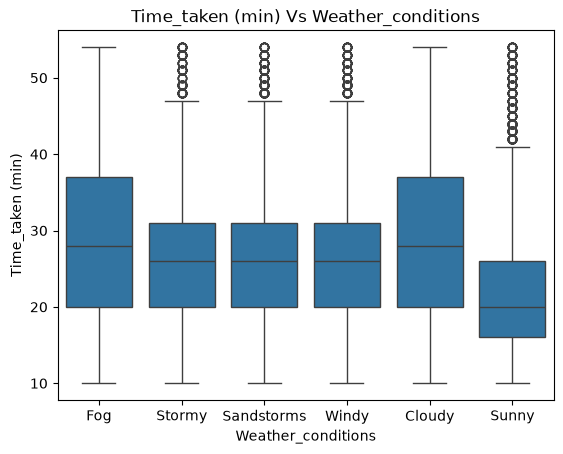

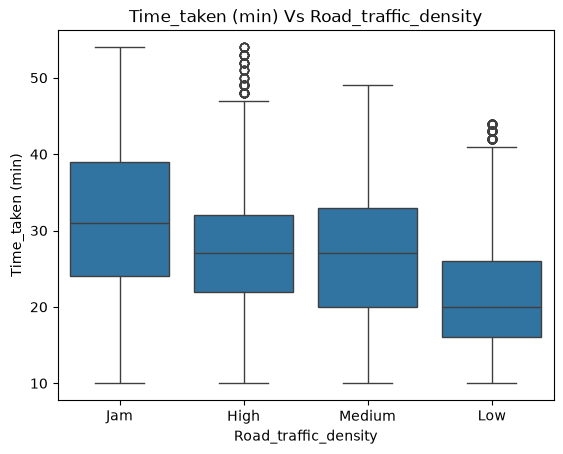

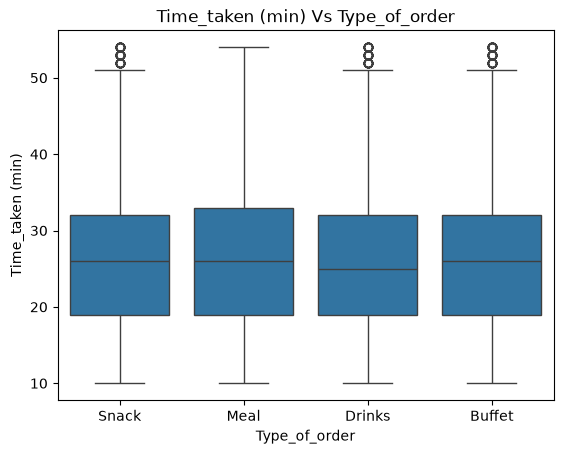

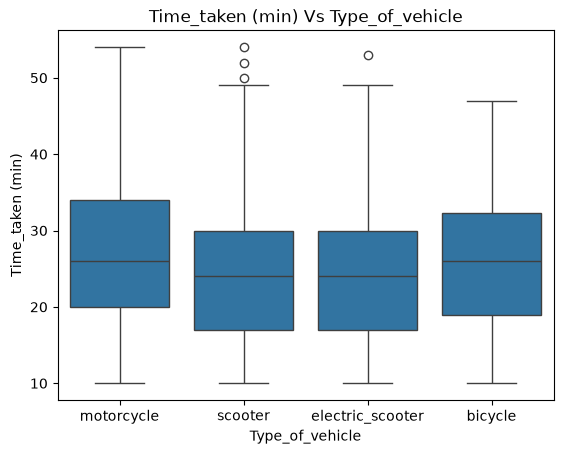

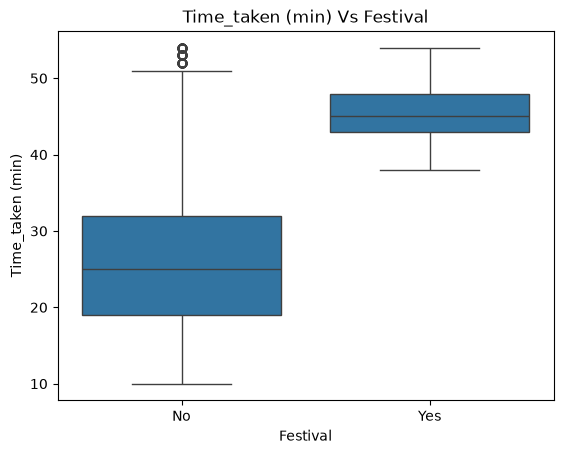

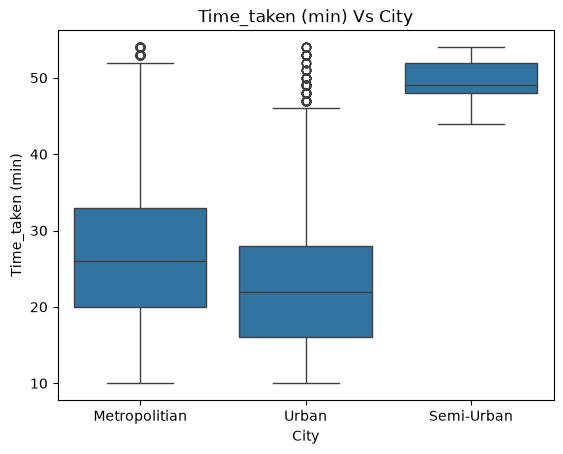

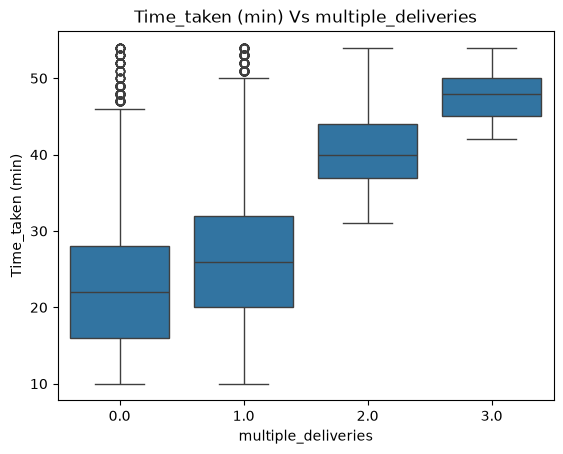

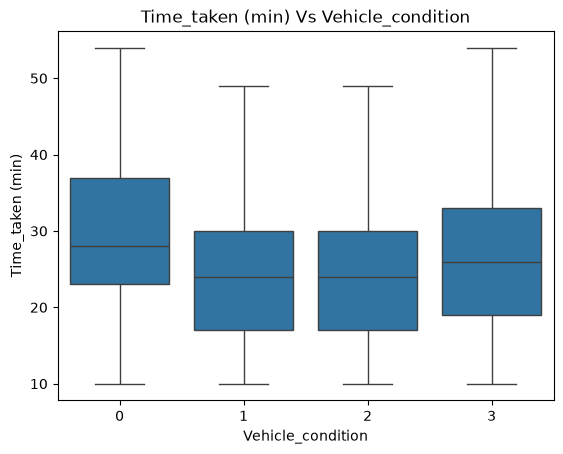

In [226]:
# Categorical Vs Target

for col in cat_col:
    sns.boxplot(data=df, x=col, y='Time_taken (min)')
    plt.title(f"Time_taken (min) Vs {col}")
    plt.show()


conclusion-


1. sunny weather has lowest delivery time while foggy and cloudy weather have higher delivery time . the diff between other weather categories is small

2. The low traffic has the lower delivery time while heavily jam has higher delivery time . so we can say that as triffic density increases , delivery time also increases . 

3. Delivery time across all the order type category is almost same .Delivery time does not varies across order type category

4. The motorcycle and bicycle takes slightly more time than scooter and electric scooter for delivery. 

5. Festival orders take much longer than non-festival orders.

6. The delivery time varies with large diff among the different city type . The semi-urban type orders take mush higher delivery time while urban take lowest derivery time.

7. The delivery time increses as the multiple delivery(no. of items) increase. The orders with 2-3 multiple delivery take much longer time than orders with 0-1 multiple deliveries.

8. For vehicle condition 0 take slightly higher delivery time than other categories , but categories overlap strongly.



The some category features shows strong relationship with Deliery time (Target) like - city, multiple_deliveries, festival, road_traffic_density these features are very  useful for our prediction.



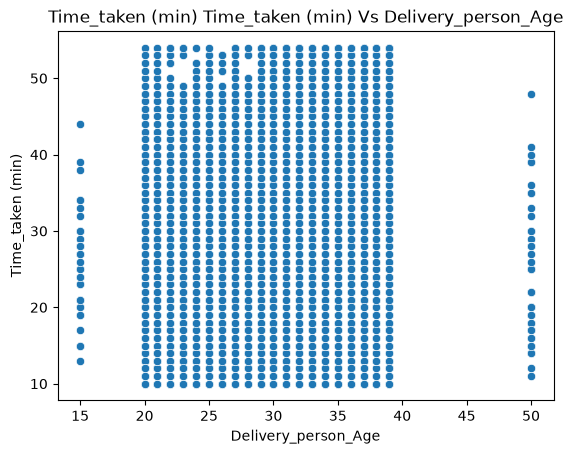

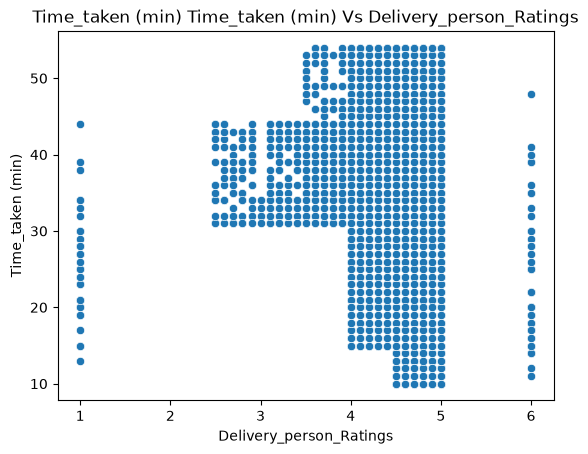

In [227]:
#  numeric Vs Target

for col in num_col:
    sns.scatterplot(data=df, x=col, y='Time_taken (min)')
    plt.title(f"Time_taken (min) Time_taken (min) Vs {col}")
    plt.show()

conclusion -

- The both scatterplot shows that there is no clear relationship of delivery person age and rating with Delivery time (Target). These features have very weak relationship with delivery time, so we can ignore this column. Also 15 & 50 age and 1 & 6 rating are suspecious

In [228]:
df.head()

,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,Time_Order_picked,Weather_conditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken (min)
0,0xcdcd,DEHRES17DEL01,36.0,4.2,30.327968,78.046106,30.397968,78.116106,12-02-2022,21:55,22:10,Fog,Jam,2,Snack,motorcycle,3.0,No,Metropolitian,46
1,0xd987,KOCRES16DEL01,21.0,4.7,10.003064,76.307589,10.043064,76.347589,13-02-2022,14:55,15:05,Stormy,High,1,Meal,motorcycle,1.0,No,Metropolitian,23
2,0x2784,PUNERES13DEL03,23.0,4.7,18.562450,73.916619,18.652450,74.006619,04-03-2022,17:30,17:40,Sandstorms,Medium,1,Drinks,scooter,1.0,No,Metropolitian,21
3,0xc8b6,LUDHRES15DEL02,34.0,4.3,30.899584,75.809346,30.919584,75.829346,13-02-2022,09:20,09:30,Sandstorms,Low,0,Buffet,motorcycle,0.0,No,Metropolitian,20
4,0xdb64,KNPRES14DEL02,24.0,4.7,26.463504,80.372929,26.593504,80.502929,14-02-2022,19:50,20:05,Fog,Jam,1,Snack,scooter,1.0,No,Metropolitian,41


In [229]:
# feature engineering on Delivery_person_ID 

df['Delivery_person_ID'].nunique()

1320

In [230]:
df['Delivery_person_ID'].isnull().sum()

np.int64(0)

In [231]:
df['Delivery_person_ID'].value_counts().head(10)

Delivery_person_ID
JAPRES11DEL02       67
PUNERES01DEL01      67
RANCHIRES02DEL01    66
VADRES11DEL02       66
JAPRES03DEL01       66
HYDRES04DEL02       66
VADRES08DEL02       66
SURRES11DEL01       65
INDORES08DEL02      65
VADRES11DEL01       65
Name: count, dtype: int64

In [232]:
df['Restuarant_ID']=df['Delivery_person_ID'].str.rsplit('DEL', n=1).str[0].str.strip()

In [233]:
df['DEL_person_ID']="DEL" + df['Delivery_person_ID'].str.rsplit('DEL', n=1).str[1].str.strip()

In [234]:
df.head()

,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,...,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken (min),Restuarant_ID,DEL_person_ID
0,0xcdcd,DEHRES17DEL01,36.0,4.2,30.327968,78.046106,30.397968,78.116106,12-02-2022,21:55,...,Jam,2,Snack,motorcycle,3.0,No,Metropolitian,46,DEHRES17,DEL01
1,0xd987,KOCRES16DEL01,21.0,4.7,10.003064,76.307589,10.043064,76.347589,13-02-2022,14:55,...,High,1,Meal,motorcycle,1.0,No,Metropolitian,23,KOCRES16,DEL01
2,0x2784,PUNERES13DEL03,23.0,4.7,18.562450,73.916619,18.652450,74.006619,04-03-2022,17:30,...,Medium,1,Drinks,scooter,1.0,No,Metropolitian,21,PUNERES13,DEL03
3,0xc8b6,LUDHRES15DEL02,34.0,4.3,30.899584,75.809346,30.919584,75.829346,13-02-2022,09:20,...,Low,0,Buffet,motorcycle,0.0,No,Metropolitian,20,LUDHRES15,DEL02
4,0xdb64,KNPRES14DEL02,24.0,4.7,26.463504,80.372929,26.593504,80.502929,14-02-2022,19:50,...,Jam,1,Snack,scooter,1.0,No,Metropolitian,41,KNPRES14,DEL02


In [235]:
df['Restuarant_ID'].value_counts()

Restuarant_ID
JAPRES09       182
JAPRES02       181
JAPRES11       178
RANCHIRES02    177
JAPRES17       176
              ... 
KOCRES12        30
AGRRES02        29
BHPRES17        29
DEHRES18        29
KOCRES19        29
Name: count, Length: 440, dtype: int64

In [236]:
df['City_Name']=df['Restuarant_ID'].str.split('RES',n=1).str[0].str.strip()

In [237]:
df['City_Name'].value_counts()

City_Name
JAP       3443
RANCHI    3228
BANG      3193
SUR       3187
HYD       3179
MUM       3173
MYS       3170
COIMB     3169
VAD       3166
INDO      3158
CHEN      3144
PUNE      3132
AGR        763
LUDH       758
KNP        740
ALH        740
DEH        737
GOA        709
AURG       703
KOC        701
KOL        700
BHP        691
Name: count, dtype: int64

In [238]:
# total count of cities

df['City_Name'].nunique()

22

In [239]:
df.head()

,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,...,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken (min),Restuarant_ID,DEL_person_ID,City_Name
0,0xcdcd,DEHRES17DEL01,36.0,4.2,30.327968,78.046106,30.397968,78.116106,12-02-2022,21:55,...,2,Snack,motorcycle,3.0,No,Metropolitian,46,DEHRES17,DEL01,DEH
1,0xd987,KOCRES16DEL01,21.0,4.7,10.003064,76.307589,10.043064,76.347589,13-02-2022,14:55,...,1,Meal,motorcycle,1.0,No,Metropolitian,23,KOCRES16,DEL01,KOC
2,0x2784,PUNERES13DEL03,23.0,4.7,18.562450,73.916619,18.652450,74.006619,04-03-2022,17:30,...,1,Drinks,scooter,1.0,No,Metropolitian,21,PUNERES13,DEL03,PUNE
3,0xc8b6,LUDHRES15DEL02,34.0,4.3,30.899584,75.809346,30.919584,75.829346,13-02-2022,09:20,...,0,Buffet,motorcycle,0.0,No,Metropolitian,20,LUDHRES15,DEL02,LUDH
4,0xdb64,KNPRES14DEL02,24.0,4.7,26.463504,80.372929,26.593504,80.502929,14-02-2022,19:50,...,1,Snack,scooter,1.0,No,Metropolitian,41,KNPRES14,DEL02,KNP


In [240]:
# feature engineering on co-ordinates columns

coordinates = ['Restaurant_latitude','Restaurant_longitude','Delivery_location_latitude','Delivery_location_longitude']

In [241]:
df[coordinates].describe()

,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude
count,45584.000000,45584.000000,45584.000000,45584.000000
mean,17.017948,70.229684,17.465480,70.844161
std,8.185674,22.885575,7.335562,21.120578
min,-30.905562,-88.366217,0.010000,0.010000
25%,12.933284,73.170000,12.988453,73.280000
50%,18.551440,75.897963,18.633934,76.002574
75%,22.728163,78.044095,22.785049,78.107044
max,30.914057,88.433452,31.054057,88.563452


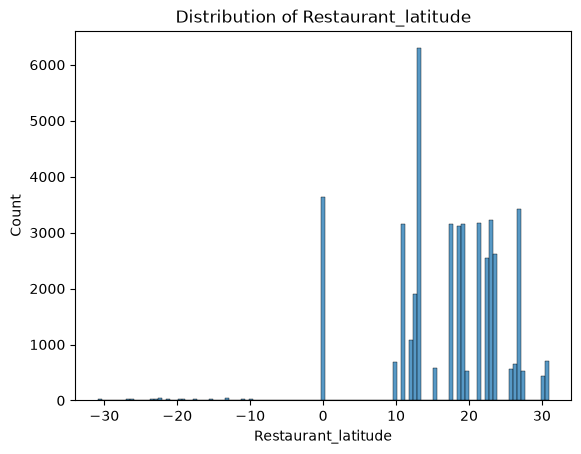

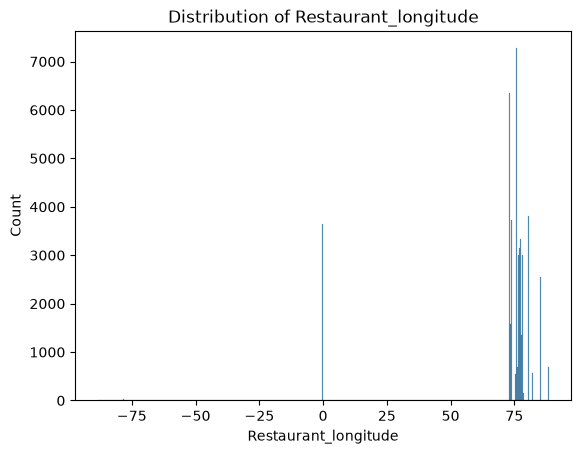

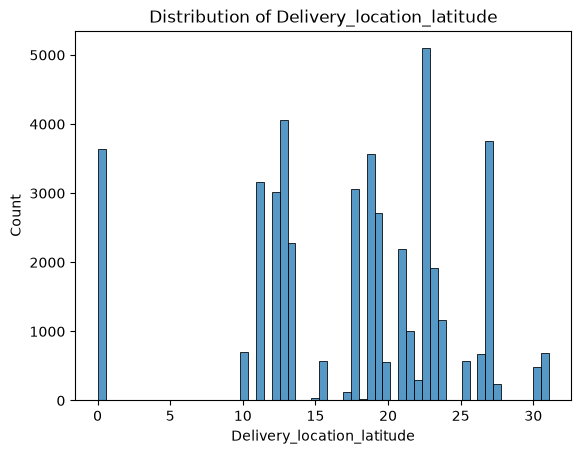

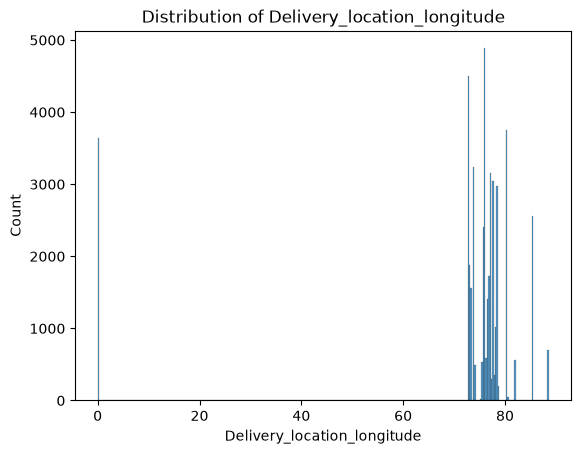

In [242]:
for col in coordinates:
    sns.histplot(data=df, x=col)
    plt.title(f"Distribution of {col}")
    plt.show()

In [243]:
# check (0,0) co-ordinates

for col in coordinates:
    print(f"{col}")
    print((df[col]==0).sum())

Restaurant_latitude
3640
Restaurant_longitude
3640
Delivery_location_latitude
0
Delivery_location_longitude
0


In [244]:
zero_rest=df[(df['Restaurant_longitude']==0) & (df['Restaurant_latitude']==0) ]

In [245]:
df[(df['Restaurant_longitude']==0) & (df['Restaurant_latitude']==0) ]['Restuarant_ID'].value_counts()

Restuarant_ID
RANCHIRES02    177
RANCHIRES12    169
VADRES09       166
VADRES12       166
VADRES16       165
RANCHIRES14    162
VADRES04       159
MYSRES14       159
VADRES18       159
VADRES02       158
VADRES07       158
RANCHIRES03    157
VADRES15       155
VADRES08       153
VADRES17       151
AURGRES16       41
BHPRES07        39
LUDHRES02       39
BHPRES12        38
DEHRES01        38
AURGRES02       38
DEHRES12        38
AGRRES09        38
AURGRES20       37
AGRRES16        37
AGRRES15        37
DEHRES20        37
ALHRES11        36
ALHRES010       36
GOARES20        36
BHPRES02        36
AGRRES19        36
AGRRES06        36
BHPRES19        35
DEHRES15        35
DEHRES02        34
DEHRES11        34
ALHRES06        34
KNPRES06        34
ALHRES09        33
ALHRES04        33
BHPRES09        33
LUDHRES07       32
AURGRES11       32
GOARES19        32
BHPRES14        32
GOARES05        32
KNPRES08        30
AGRRES02        29
DEHRES18        29
Name: count, dtype: int64

In [246]:
zero_rest.groupby('City_Name').size().sort_values(ascending=False)

City_Name
VAD       1590
RANCHI     665
DEH        245
AGR        213
BHP        213
ALH        172
MYS        159
AURG       148
GOA        100
LUDH        71
KNP         64
dtype: int64

conclusion-

Restaurant coordinates are (0,0) in 3,640 orders across 50 restuarent and 11 cities.Out of total 3,640 orders about 1590 orders are from vadodara(VAD) city restaurants. we need to do feature engineering for that.

In [247]:
df[(df['City_Name']=="VAD") & ~((df['Restaurant_longitude']==0) & (df['Restaurant_latitude']==0))]

,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,...,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken (min),Restuarant_ID,DEL_person_ID,City_Name
70,0x2dc6,VADRES20DEL01,34.0,4.7,22.311358,73.164798,22.351358,73.204798,19-03-2022,12:35,...,2,Drinks,electric_scooter,1.0,No,Metropolitian,28,VADRES20,DEL01,VAD
111,0x6e2,VADRES06DEL01,NaN,NaN,22.312790,73.170283,22.422790,73.280283,02-04-2022,NaN,...,3,Snack,electric_scooter,0.0,No,Metropolitian,25,VADRES06,DEL01,VAD
122,0x1e58,VADRES14DEL03,31.0,4.6,22.311603,73.165012,22.371603,73.225012,24-03-2022,21:20,...,0,Snack,motorcycle,0.0,No,Metropolitian,25,VADRES14,DEL03,VAD
132,0x8ed2,VADRES20DEL01,36.0,5.0,22.311358,73.164798,22.381358,73.234798,31-03-2022,19:55,...,1,Snack,motorcycle,1.0,No,Metropolitian,35,VADRES20,DEL01,VAD
150,0x87e4,VADRES13DEL03,36.0,4.0,22.310237,73.158921,22.400237,73.248921,16-03-2022,20:40,...,0,Meal,motorcycle,3.0,No,Metropolitian,44,VADRES13,DEL03,VAD
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45494,0x6ab6,VADRES11DEL02,37.0,4.7,22.308096,73.167753,22.358096,73.217753,19-03-2022,17:15,...,1,Drinks,motorcycle,1.0,No,Metropolitian,30,VADRES11,DEL02,VAD
45514,0x4b93,VADRES010DEL02,27.0,4.7,22.310329,73.169083,22.390329,73.249083,04-03-2022,19:35,...,2,Snack,scooter,1.0,No,Metropolitian,20,VADRES010,DEL02,VAD
45516,0x3830,VADRES010DEL01,31.0,4.7,22.310329,73.169083,22.350329,73.209083,03-03-2022,13:15,...,2,Snack,scooter,1.0,No,Metropolitian,33,VADRES010,DEL01,VAD
45536,0x6002,VADRES14DEL03,34.0,4.6,22.311603,73.165012,22.371603,73.225012,26-03-2022,22:45,...,1,Meal,motorcycle,1.0,No,Metropolitian,24,VADRES14,DEL03,VAD


In [248]:
# suspecious co ordinates

bad_coord = df[
    (df['Delivery_location_latitude'].abs() < 1) &
    (df['Delivery_location_longitude'].abs() < 1)
]

print(bad_coord.shape)

(3640, 23)


In [249]:
bad_coord[
    ['Restaurant_latitude',
     'Restaurant_longitude',
     'Delivery_location_latitude',
     'Delivery_location_longitude']
].describe()

,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude
count,3640.0,3640.0,3640.000000,3640.000000
mean,0.0,0.0,0.063016,0.063016
std,0.0,0.0,0.036047,0.036047
min,0.0,0.0,0.010000,0.010000
25%,0.0,0.0,0.030000,0.030000
50%,0.0,0.0,0.060000,0.060000
75%,0.0,0.0,0.090000,0.090000
max,0.0,0.0,0.130000,0.130000


In [250]:
# normal Coordinates

normal_coord = df[
    (df['Restaurant_latitude'] != 0) &
    (df['Restaurant_longitude'] != 0)
]

In [251]:
normal_coord[[
    'Restaurant_latitude',
    'Restaurant_longitude',
    'Delivery_location_latitude',
    'Delivery_location_longitude'
]].describe()

,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude
count,41944.000000,41944.000000,41944.000000,41944.000000
mean,18.494806,76.324383,18.975707,76.986717
std,6.745770,10.198903,5.469655,3.503144
min,-30.905562,-88.366217,9.967144,72.778726
25%,12.980410,73.897902,13.065996,73.940327
50%,19.003517,76.618203,19.124049,76.663067
75%,22.750040,78.347554,22.820040,78.405467
max,30.914057,88.433452,31.054057,88.563452


In [252]:
# convert suspecious co ordinates to NAN

import numpy as np

bad_coord = (
    (df['Restaurant_latitude'] == 0) &
    (df['Restaurant_longitude'] == 0)
)

df.loc[bad_coord, [
    'Restaurant_latitude',
    'Restaurant_longitude',
    'Delivery_location_latitude',
    'Delivery_location_longitude'
]] = np.nan

In [253]:
df.isnull().sum()

ID                                0
Delivery_person_ID                0
Delivery_person_Age            1854
Delivery_person_Ratings        1908
Restaurant_latitude            3640
Restaurant_longitude           3640
Delivery_location_latitude     3640
Delivery_location_longitude    3640
Order_Date                        0
Time_Orderd                    1731
Time_Order_picked                 0
Weather_conditions              616
Road_traffic_density            601
Vehicle_condition                 0
Type_of_order                     0
Type_of_vehicle                   0
multiple_deliveries             993
Festival                        228
City                           1200
Time_taken (min)                  0
Restuarant_ID                     0
DEL_person_ID                     0
City_Name                         0
dtype: int64

The 3640 suspicious records have the restaurant coordinate zero and delivery coordinate near to zero . also for every record latitude = longitude co-ordinates both are same.

In [254]:
from math import radians, sin, cos, sqrt, atan2

def haversine(row):
    lat1 = radians(row['Restaurant_latitude'])
    lon1 = radians(row['Restaurant_longitude'])
    lat2 = radians(row['Delivery_location_latitude'])
    lon2 = radians(row['Delivery_location_longitude'])

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = sin(dlat/2)**2 + cos(lat1) * cos(lat2) * sin(dlon/2)**2

    return 6371 * 2 * atan2(sqrt(a), sqrt(1-a))

df['distance_km'] = df.apply(haversine, axis=1)

In [255]:
df.head()

,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,...,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken (min),Restuarant_ID,DEL_person_ID,City_Name,distance_km
0,0xcdcd,DEHRES17DEL01,36.0,4.2,30.327968,78.046106,30.397968,78.116106,12-02-2022,21:55,...,Snack,motorcycle,3.0,No,Metropolitian,46,DEHRES17,DEL01,DEH,10.280582
1,0xd987,KOCRES16DEL01,21.0,4.7,10.003064,76.307589,10.043064,76.347589,13-02-2022,14:55,...,Meal,motorcycle,1.0,No,Metropolitian,23,KOCRES16,DEL01,KOC,6.242319
2,0x2784,PUNERES13DEL03,23.0,4.7,18.562450,73.916619,18.652450,74.006619,04-03-2022,17:30,...,Drinks,scooter,1.0,No,Metropolitian,21,PUNERES13,DEL03,PUNE,13.787860
3,0xc8b6,LUDHRES15DEL02,34.0,4.3,30.899584,75.809346,30.919584,75.829346,13-02-2022,09:20,...,Buffet,motorcycle,0.0,No,Metropolitian,20,LUDHRES15,DEL02,LUDH,2.930258
4,0xdb64,KNPRES14DEL02,24.0,4.7,26.463504,80.372929,26.593504,80.502929,14-02-2022,19:50,...,Snack,scooter,1.0,No,Metropolitian,41,KNPRES14,DEL02,KNP,19.396618


In [256]:
df['distance_km'].describe()

count    41944.000000
mean       107.080686
std       1146.240729
min          1.465067
25%          4.658001
50%          9.220368
75%         13.760880
max      19692.674606
Name: distance_km, dtype: float64

In [257]:
df.nlargest(10, 'distance_km')[
    [
        'Restaurant_latitude',
        'Restaurant_longitude',
        'Delivery_location_latitude',
        'Delivery_location_longitude',
        'distance_km',
        'City_Name',
        'Restuarant_ID'
    ]
]

,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,distance_km,City_Name,Restuarant_ID
33524,-22.533662,-88.366217,22.663662,88.496217,19692.674606,KOL,KOLRES06
6779,-22.552672,-88.352885,22.662672,88.462885,19688.001288,KOL,KOLRES15
2475,-22.538999,-88.322337,22.668999,88.452337,19683.687561,KOL,KOLRES010
18817,-22.537960,-88.349843,22.547960,88.359843,19677.180552,KOL,KOLRES08
9526,-23.374989,-85.335486,23.444989,85.405486,19070.408110,RANCHI,RANCHIRES13
753,-23.359194,-85.325447,23.449194,85.415447,19070.337839,RANCHI,RANCHIRES11
35526,-23.369746,-85.339820,23.419746,85.389820,19069.158946,RANCHI,RANCHIRES15
22282,-23.351058,-85.325731,23.421058,85.395731,19068.246962,RANCHI,RANCHIRES09
30624,-23.357804,-85.325146,23.417804,85.385146,19067.128547,RANCHI,RANCHIRES06
43445,-23.351058,-85.325731,23.401058,85.375731,19066.150742,RANCHI,RANCHIRES09


In [258]:
bad_sign = (
    (df['Restaurant_latitude'] < 0) &
    (df['Restaurant_longitude'] < 0) &
    (df['Delivery_location_latitude'] > 0) &
    (df['Delivery_location_longitude'] > 0)
)

bad_sign.sum()

np.int64(162)

In [259]:
df[bad_sign][[
    'Restaurant_latitude',
    'Restaurant_longitude',
    'Delivery_location_latitude',
    'Delivery_location_longitude',
    'City_Name'
]].head(10)

,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,City_Name
280,-18.551440,-73.804855,18.611440,73.864855,PUNE
416,-30.366322,-78.070453,30.496322,78.200453,DEH
525,-12.325461,-76.632278,12.385461,76.692278,MYS
753,-23.359194,-85.325447,23.449194,85.415447,RANCHI
1050,-26.477750,-80.351569,26.487750,80.361569,KNP
1277,-27.160934,-78.044095,27.180934,78.064095,AGR
1369,-26.905190,-75.810753,26.975190,75.880753,JAP
1590,-19.176269,-72.836721,19.256269,72.916721,MUM
2247,-27.161850,-78.040165,27.251850,78.130165,AGR
2342,-18.520016,-73.830547,18.580016,73.890547,PUNE


In [260]:
df[df['Restuarant_ID']=='KOLRES010'][['Restuarant_ID','Restaurant_latitude','Restaurant_longitude','Delivery_location_latitude','Delivery_location_longitude']].head()

,Restuarant_ID,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude
2475,KOLRES010,-22.538999,-88.322337,22.668999,88.452337
3157,KOLRES010,22.538999,88.322337,22.628999,88.412337
3302,KOLRES010,22.538999,88.322337,22.588999,88.372337
5876,KOLRES010,22.538999,88.322337,22.668999,88.452337
6026,KOLRES010,22.538999,88.322337,22.608999,88.392336


conclusion-

There are total 162 records have negative restaurant coordinates but in originally they have posistive co-ordinates for same restaurant, because of this calculated distance(max) becames 19,692 km which is not reliable .So we need to flip their sign to make co-ordinate correct. Also the india's co- ordinate are alway positive

In [261]:
# so flip the sign of -ve co ordinate

df['Restaurant_latitude'] = df['Restaurant_latitude'].abs()
df['Restaurant_longitude'] = df['Restaurant_longitude'].abs()

In [262]:
from math import radians, sin, cos, sqrt, atan2

def haversine(row):
    lat1 = radians(row['Restaurant_latitude'])
    lon1 = radians(row['Restaurant_longitude'])
    lat2 = radians(row['Delivery_location_latitude'])
    lon2 = radians(row['Delivery_location_longitude'])

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = sin(dlat/2)**2 + cos(lat1) * cos(lat2) * sin(dlon/2)**2

    return 6371 * 2 * atan2(sqrt(a), sqrt(1-a))

df['distance_km'] = df.apply(haversine, axis=1)

In [263]:
df['distance_km'].describe()

count    41944.000000
mean         9.719982
std          5.602566
min          1.465067
25%          4.657655
50%          9.193021
75%         13.680920
max         20.969489
Name: distance_km, dtype: float64

<Axes: xlabel='distance_km', ylabel='Count'>

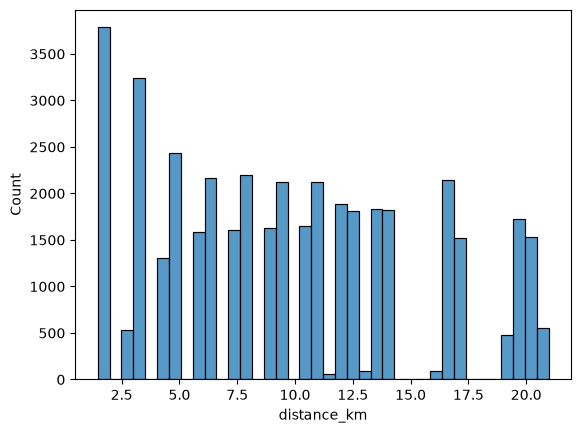

In [264]:
sns.histplot(df['distance_km'])

<Axes: xlabel='distance_km', ylabel='Density'>

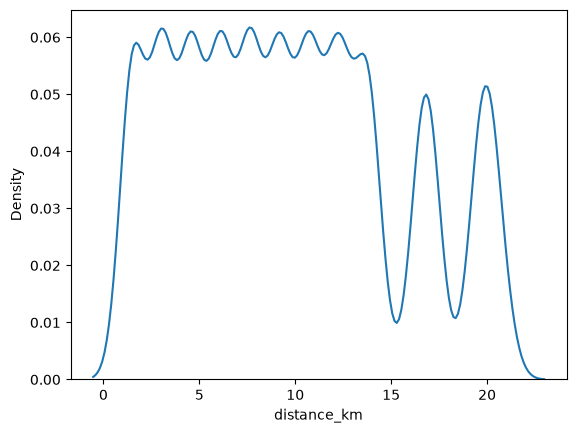

In [265]:
sns.kdeplot(df['distance_km'])

<Axes: xlabel='distance_km', ylabel='Time_taken (min)'>

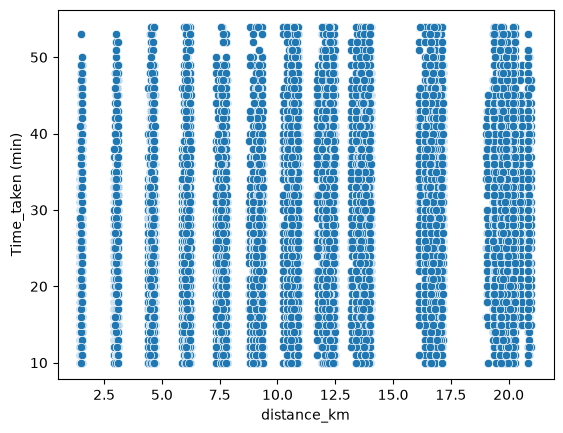

In [266]:
# distance_km Vs Time taken

sns.scatterplot(data=df, x='distance_km', y='Time_taken (min)')

conclusion-

the distance alone does not shows the direct strong relaionship with the target . the other features like weather ,traffic, city, also plays important role here.

In [267]:
# feature engineering on date column

df['Order_Date'].describe()

count          45584
unique            44
top       15-03-2022
freq            1192
Name: Order_Date, dtype: object

In [268]:
df['Order_Date'].dtype

<StringDtype(na_value=nan)>

In [269]:
df['Order_Date'] = pd.to_datetime(
    df['Order_Date'],
    format='%d-%m-%Y'
)

In [270]:
df['Order_Date'].dtype

dtype('<M8[us]')

In [271]:
df['Order_Date'].head()

0   2022-02-12
1   2022-02-13
2   2022-03-04
3   2022-02-13
4   2022-02-14
Name: Order_Date, dtype: datetime64[us]

In [272]:
df['Order_Date'].value_counts()

Order_Date
2022-03-15    1192
2022-04-03    1178
2022-03-13    1169
2022-03-26    1165
2022-03-24    1162
2022-03-09    1159
2022-04-05    1156
2022-03-05    1154
2022-03-07    1153
2022-03-03    1150
2022-03-21    1149
2022-03-11    1148
2022-03-19    1148
2022-03-30    1141
2022-03-01    1140
2022-03-28    1139
2022-03-17    1134
2022-04-01    1133
2022-03-02    1012
2022-03-10     996
2022-03-16     995
2022-03-20     993
2022-04-02     992
2022-03-06     986
2022-03-04     980
2022-03-29     977
2022-03-25     974
2022-03-14     973
2022-02-11     970
2022-03-18     968
2022-03-31     967
2022-03-27     965
2022-03-12     964
2022-03-08     964
2022-03-23     964
2022-04-06     961
2022-02-13     957
2022-02-15     945
2022-04-04     941
2022-02-17     939
2022-02-12     864
2022-02-16     861
2022-02-18     855
2022-02-14     851
Name: count, dtype: int64

In [273]:
df['order_day'] = df['Order_Date'].dt.day
df['order_month'] = df['Order_Date'].dt.month
df['order_dayofweek'] = df['Order_Date'].dt.dayofweek
df['is_weekend'] = df['order_dayofweek'].isin([5, 6]).astype(int)

In [274]:
df.head()

,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,...,City,Time_taken (min),Restuarant_ID,DEL_person_ID,City_Name,distance_km,order_day,order_month,order_dayofweek,is_weekend
0,0xcdcd,DEHRES17DEL01,36.0,4.2,30.327968,78.046106,30.397968,78.116106,2022-02-12,21:55,...,Metropolitian,46,DEHRES17,DEL01,DEH,10.280582,12,2,5,1
1,0xd987,KOCRES16DEL01,21.0,4.7,10.003064,76.307589,10.043064,76.347589,2022-02-13,14:55,...,Metropolitian,23,KOCRES16,DEL01,KOC,6.242319,13,2,6,1
2,0x2784,PUNERES13DEL03,23.0,4.7,18.562450,73.916619,18.652450,74.006619,2022-03-04,17:30,...,Metropolitian,21,PUNERES13,DEL03,PUNE,13.787860,4,3,4,0
3,0xc8b6,LUDHRES15DEL02,34.0,4.3,30.899584,75.809346,30.919584,75.829346,2022-02-13,09:20,...,Metropolitian,20,LUDHRES15,DEL02,LUDH,2.930258,13,2,6,1
4,0xdb64,KNPRES14DEL02,24.0,4.7,26.463504,80.372929,26.593504,80.502929,2022-02-14,19:50,...,Metropolitian,41,KNPRES14,DEL02,KNP,19.396618,14,2,0,0


<Axes: xlabel='order_day', ylabel='Count'>

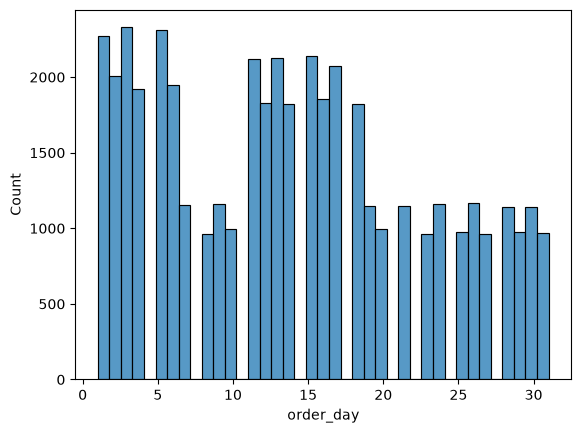

In [275]:
sns.histplot(df['order_day'])

<Axes: xlabel='order_day', ylabel='Time_taken (min)'>

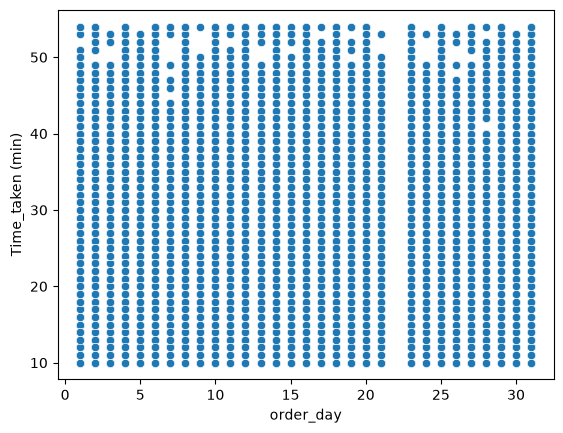

In [276]:
sns.scatterplot(data=df,x='order_day',y='Time_taken (min)')

In [277]:
colm=['order_dayofweek','order_month','is_weekend']

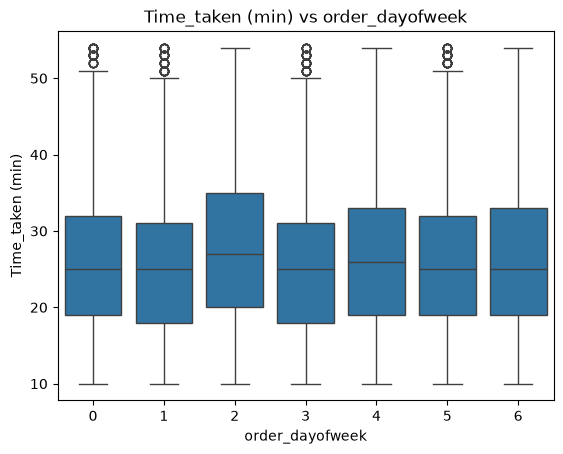

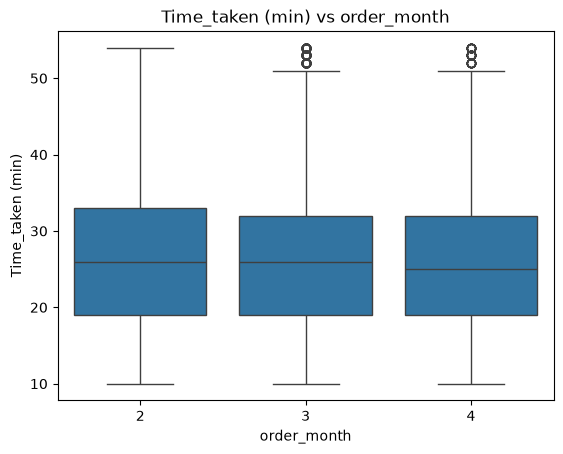

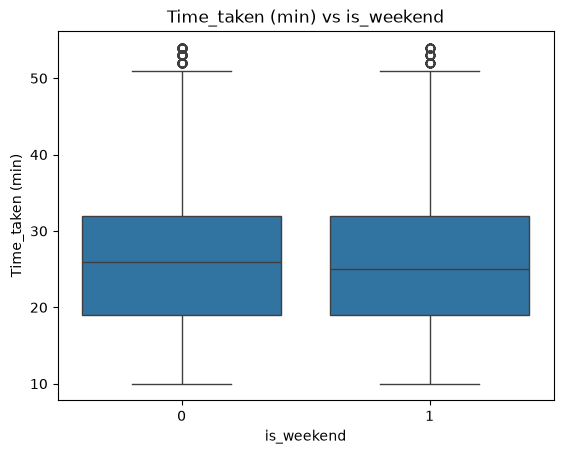

In [278]:
for col in colm:
    sns.boxplot(data=df,x=col,y='Time_taken (min)')
    plt.title(f"Time_taken (min) vs {col}")
    plt.show()

conclusion -


These column does not affect the target directly , there is not strong relationship with target.

In [279]:
# Time order 

df['Time_Orderd'].dtype

<StringDtype(na_value=nan)>

In [287]:
df['Time_Orderd'].nunique()



176

In [288]:
def time_to_minutes(x):
    if pd.isna(x):
        return np.nan

    x = str(x).strip()

    if ':' in x:
        h, m = x.split(':')[:2]
        return int(h) * 60 + int(m)

    return float(x) * 24 * 60


In [289]:
df['order_min'] = df['Time_Orderd'].apply(time_to_minutes)
df['pickup_min'] = df['Time_Order_picked'].apply(time_to_minutes)

In [291]:
df[['order_min','pickup_min']].describe()

,order_min,pickup_min
count,43853.000000,45584.000000
mean,1089.132671,1098.997565
std,272.260985,272.521980
min,490.000000,495.000000
25%,950.000000,960.000000
50%,1160.000000,1170.000000
75%,1300.000000,1310.000000
max,1440.000000,1455.000000


In [292]:
df['order_to_pickup_min'] = df['pickup_min'] - df['order_min']

In [293]:
df['order_to_pickup_min'].describe()

count    43853.000000
mean         9.989168
std          4.087516
min          5.000000
25%          5.000000
50%         10.000000
75%         15.000000
max         15.000000
Name: order_to_pickup_min, dtype: float64

<Axes: xlabel='order_to_pickup_min', ylabel='Time_taken (min)'>

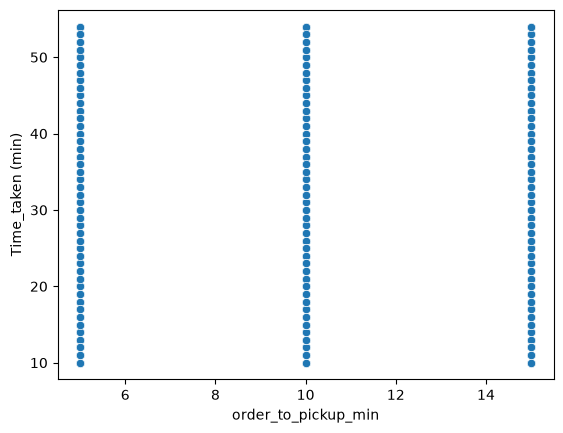

In [294]:
sns.scatterplot(data=df,x='order_to_pickup_min',y='Time_taken (min)')

In [295]:
num_cols = [
    'Delivery_person_Age',
    'Delivery_person_Ratings',
    'Vehicle_condition',
    'multiple_deliveries',
    'distance_km',
    'order_to_pickup_min',
    'order_day'
]

df[num_cols + ['Time_taken (min)']].corr()['Time_taken (min)'].sort_values(
    ascending=False
)

Time_taken (min)           1.000000
multiple_deliveries        0.387042
distance_km                0.320474
Delivery_person_Age        0.299523
order_day                  0.023974
order_to_pickup_min       -0.008487
Vehicle_condition         -0.234456
Delivery_person_Ratings   -0.338814
Name: Time_taken (min), dtype: float64

In [296]:
# drop invalid rows which contain outliers in age and rating 91 rows

df = df[~df['Delivery_person_Ratings'].isin([1, 6])]

In [297]:
df.shape

(45493, 31)

In [298]:
drop_cols = [
    'ID',
    'Delivery_person_ID',
    'Restaurant_latitude',
    'Restaurant_longitude',
    'Delivery_location_latitude',
    'Delivery_location_longitude',
    'Order_Date',
    'Time_Orderd',
    'Time_Order_picked',
    'DEL_person_ID',
    'Restuarant_ID',
    "Delivery_person_Age",
    'pickup_min',
    'order_min'

]

df = df.drop(columns=drop_cols)

In [299]:
df.isnull().sum()

Delivery_person_Ratings    1908
Weather_conditions          525
Road_traffic_density        510
Vehicle_condition             0
Type_of_order                 0
Type_of_vehicle               0
multiple_deliveries         993
Festival                    228
City                       1198
Time_taken (min)              0
City_Name                     0
distance_km                3630
order_day                     0
order_month                   0
order_dayofweek               0
is_weekend                    0
order_to_pickup_min        1640
dtype: int64

In [ ]:
df